# 🔬 HAM10000 — Класифікація шкірних уражень
**Комп'ютерний зір | Transfer Learning | EfficientNet-B3**

---
## Задача
Багатокласова класифікація дерматоскопічних зображень на 7 типів шкірних уражень:
- **MEL** — Melanoma (меланома)
- **NV** — Melanocytic nevi (невуси)
- **BCC** — Basal cell carcinoma (базаліома)
- **AKIEC** — Actinic keratoses (актинічний кератоз)
- **BKL** — Benign keratosis (доброякісний кератоз)
- **DF** — Dermatofibroma (дерматофіброма)
- **VASC** — Vascular lesions (судинні ураження)

> ⚠️ **Disclaimer**: Ця модель створена в навчальних цілях. Не є медичним діагнозом. Завжди консультуйтесь з дерматологом.

## 1. Встановлення залежностей

In [ ]:
# Якщо запускаєш вперше — розкоментуй:
# !pip install torch torchvision timm kagglehub grad-cam scikit-learn matplotlib seaborn pandas pillow tqdm

## 2. Імпорти

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, roc_auc_score, accuracy_score
)

# Відтворюваність
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Device: cpu


## 3. Завантаження датасету

In [2]:
import kagglehub

path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")
print(f"📁 Dataset path: {path}")

IMG_DIR  = os.path.join(path, "images")
MASK_DIR = os.path.join(path, "masks")
CSV_PATH = os.path.join(path, "GroundTruth.csv")

df = pd.read_csv(CSV_PATH)
print(f"\n📊 Shape: {df.shape}")
df.head()

📁 Dataset path: /Users/artemlotariev/.cache/kagglehub/datasets/surajghuwalewala/ham1000-segmentation-and-classification/versions/2

📊 Shape: (10015, 8)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
0,ISIC_0024306,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0024307,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0024308,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0024309,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0024310,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. EDA — Exploratory Data Analysis

In [3]:
# Назви класів
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
CLASS_LABELS = {
    'MEL':   'Melanoma',
    'NV':    'Melanocytic nevi',
    'BCC':   'Basal cell carcinoma',
    'AKIEC': 'Actinic keratoses',
    'BKL':   'Benign keratosis',
    'DF':    'Dermatofibroma',
    'VASC':  'Vascular lesions'
}

# Перетворення one-hot -> label
df['label'] = df[CLASS_NAMES].values.argmax(axis=1)
df['class_name'] = df['label'].apply(lambda x: CLASS_NAMES[x])

# Підрахунок класів
class_counts = df['class_name'].value_counts().reindex(CLASS_NAMES)
print("Розподіл класів:")
print(class_counts)
print(f"\nЗагальна кількість зображень: {len(df)}")

Розподіл класів:
class_name
MEL      1113
NV       6705
BCC       514
AKIEC     327
BKL      1099
DF        115
VASC      142
Name: count, dtype: int64

Загальна кількість зображень: 10015


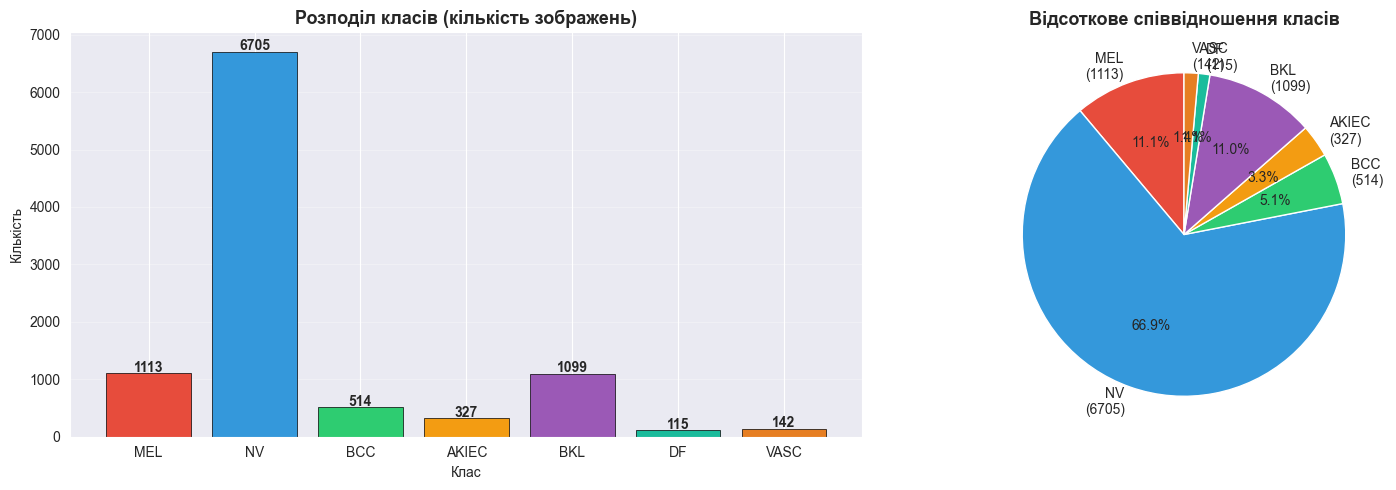


⚠️  Дисбаланс класів: 58.3x (max/min)
→ Будемо використовувати WeightedRandomSampler для балансування


In [4]:
# Візуалізація розподілу класів
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

# Bar chart
axes[0].bar(CLASS_NAMES, class_counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Розподіл класів (кількість зображень)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Клас')
axes[0].set_ylabel('Кількість')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(class_counts.values, labels=[f'{n}\n({v})' for n, v in zip(CLASS_NAMES, class_counts.values)],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Відсоткове співвідношення класів', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Imbalance ratio
max_count = class_counts.max()
min_count = class_counts.min()
print(f"\n⚠️  Дисбаланс класів: {max_count/min_count:.1f}x (max/min)")
print("→ Будемо використовувати WeightedRandomSampler для балансування")

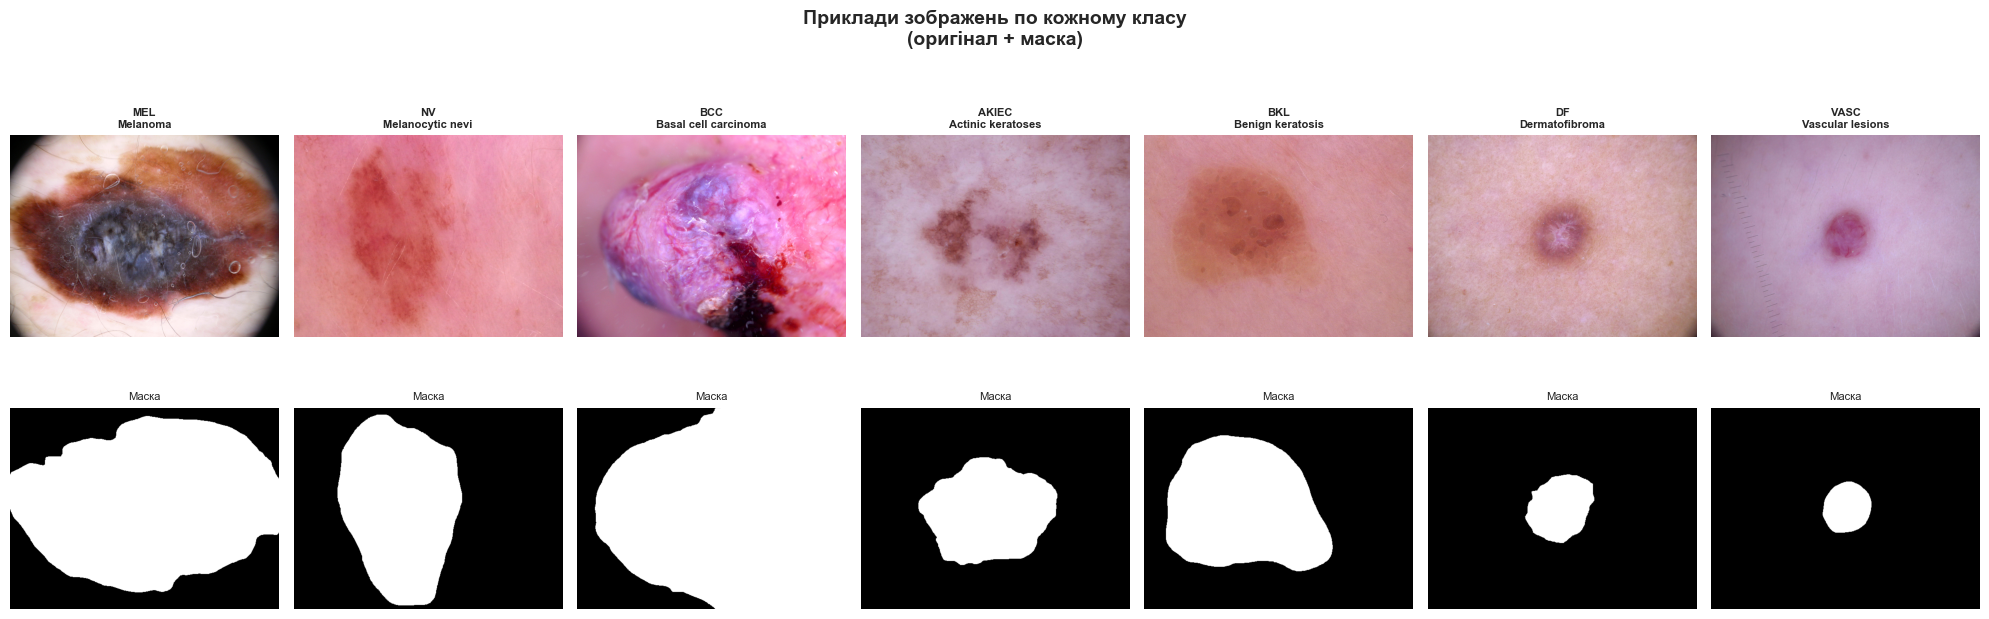

In [5]:
# Приклади зображень по кожному класу
fig, axes = plt.subplots(2, 7, figsize=(20, 7))
fig.suptitle('Приклади зображень по кожному класу\n(оригінал + маска)', fontsize=14, fontweight='bold')

for col, cls in enumerate(CLASS_NAMES):
    sample = df[df['class_name'] == cls].sample(1).iloc[0]
    img_path  = os.path.join(IMG_DIR,  sample['image'] + '.jpg')
    mask_path = os.path.join(MASK_DIR, sample['image'] + '_segmentation.png')

    img = Image.open(img_path).convert('RGB')
    axes[0, col].imshow(img)
    axes[0, col].set_title(f'{cls}\n{CLASS_LABELS[cls]}', fontsize=8, fontweight='bold')
    axes[0, col].axis('off')

    if os.path.exists(mask_path):
        mask = Image.open(mask_path).convert('L')
        axes[1, col].imshow(mask, cmap='gray')
        axes[1, col].set_title('Маска', fontsize=8)
    else:
        axes[1, col].text(0.5, 0.5, 'Маска\nвідсутня', ha='center', va='center', transform=axes[1,col].transAxes)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Аналіз розмірів зображень
print("Аналіз розмірів зображень (перші 200)...")
widths, heights = [], []
sample_imgs = df['image'].sample(min(200, len(df))).tolist()

for img_name in tqdm(sample_imgs):
    img_path = os.path.join(IMG_DIR, img_name + '.jpg')
    if os.path.exists(img_path):
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print(f"Ширина:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
print(f"Висота:  min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")
print(f"\n→ Будемо ресайзити до 224x224 для EfficientNet")

Аналіз розмірів зображень (перші 200)...


100%|██████████| 200/200 [00:00<00:00, 4981.06it/s]

Ширина:  min=600, max=600, mean=600
Висота:  min=450, max=450, mean=450

→ Будемо ресайзити до 224x224 для EfficientNet


## 5. Підготовка даних

Train: 7010 | Val: 1502 | Test: 1503


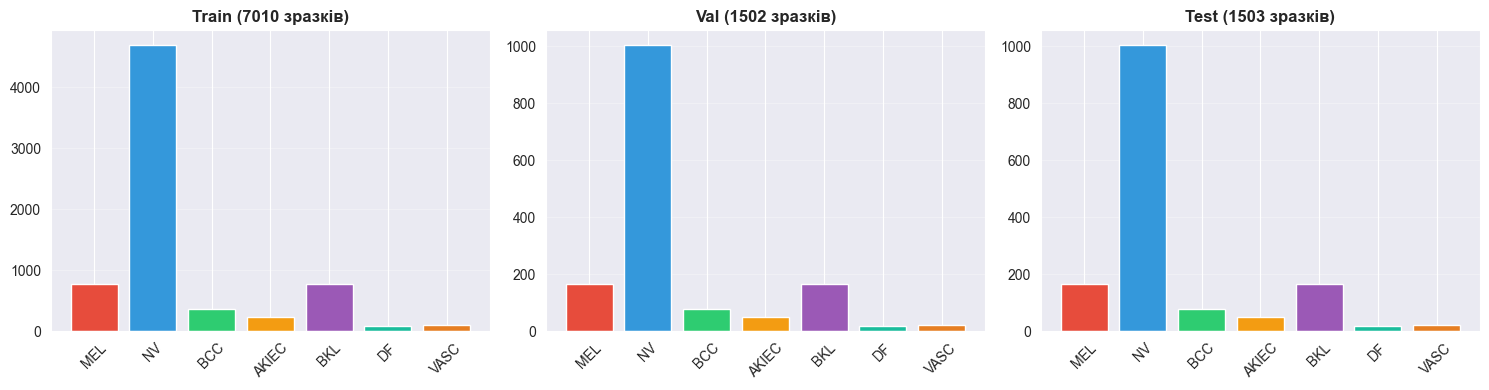

In [7]:
# Train / Val / Test split — 70 / 15 / 15
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Перевірка розподілу
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, subset, name in zip(axes, [train_df, val_df, test_df], ['Train', 'Val', 'Test']):
    counts = subset['class_name'].value_counts().reindex(CLASS_NAMES)
    ax.bar(CLASS_NAMES, counts.values, color=colors)
    ax.set_title(f'{name} ({len(subset)} зразків)', fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=45)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('splits_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Dataset class
class HAMDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'] + '.jpg')
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])
        if self.transform:
            image = self.transform(image)
        return image, label


# ImageNet mean/std для pretrained моделей
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Datasets
train_dataset = HAMDataset(train_df, IMG_DIR, train_transform)
val_dataset   = HAMDataset(val_df,   IMG_DIR, val_test_transform)
test_dataset  = HAMDataset(test_df,  IMG_DIR, val_test_transform)

print(f"✅ Datasets created")
print(f"   Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

✅ Datasets created
   Train: 7010 | Val: 1502 | Test: 1503


In [16]:
# WeightedRandomSampler — вирішуємо дисбаланс класів
class_counts_train = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts_train, dtype=torch.float)

sample_weights = class_weights[train_df['label'].values]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders
BATCH_SIZE = 32
NUM_WORKERS = 0  # зменш до 0 якщо помилки на Windows

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=False)

print(f"✅ DataLoaders ready")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

✅ DataLoaders ready
   Batch size: 32
   Train batches: 220 | Val: 47 | Test: 47


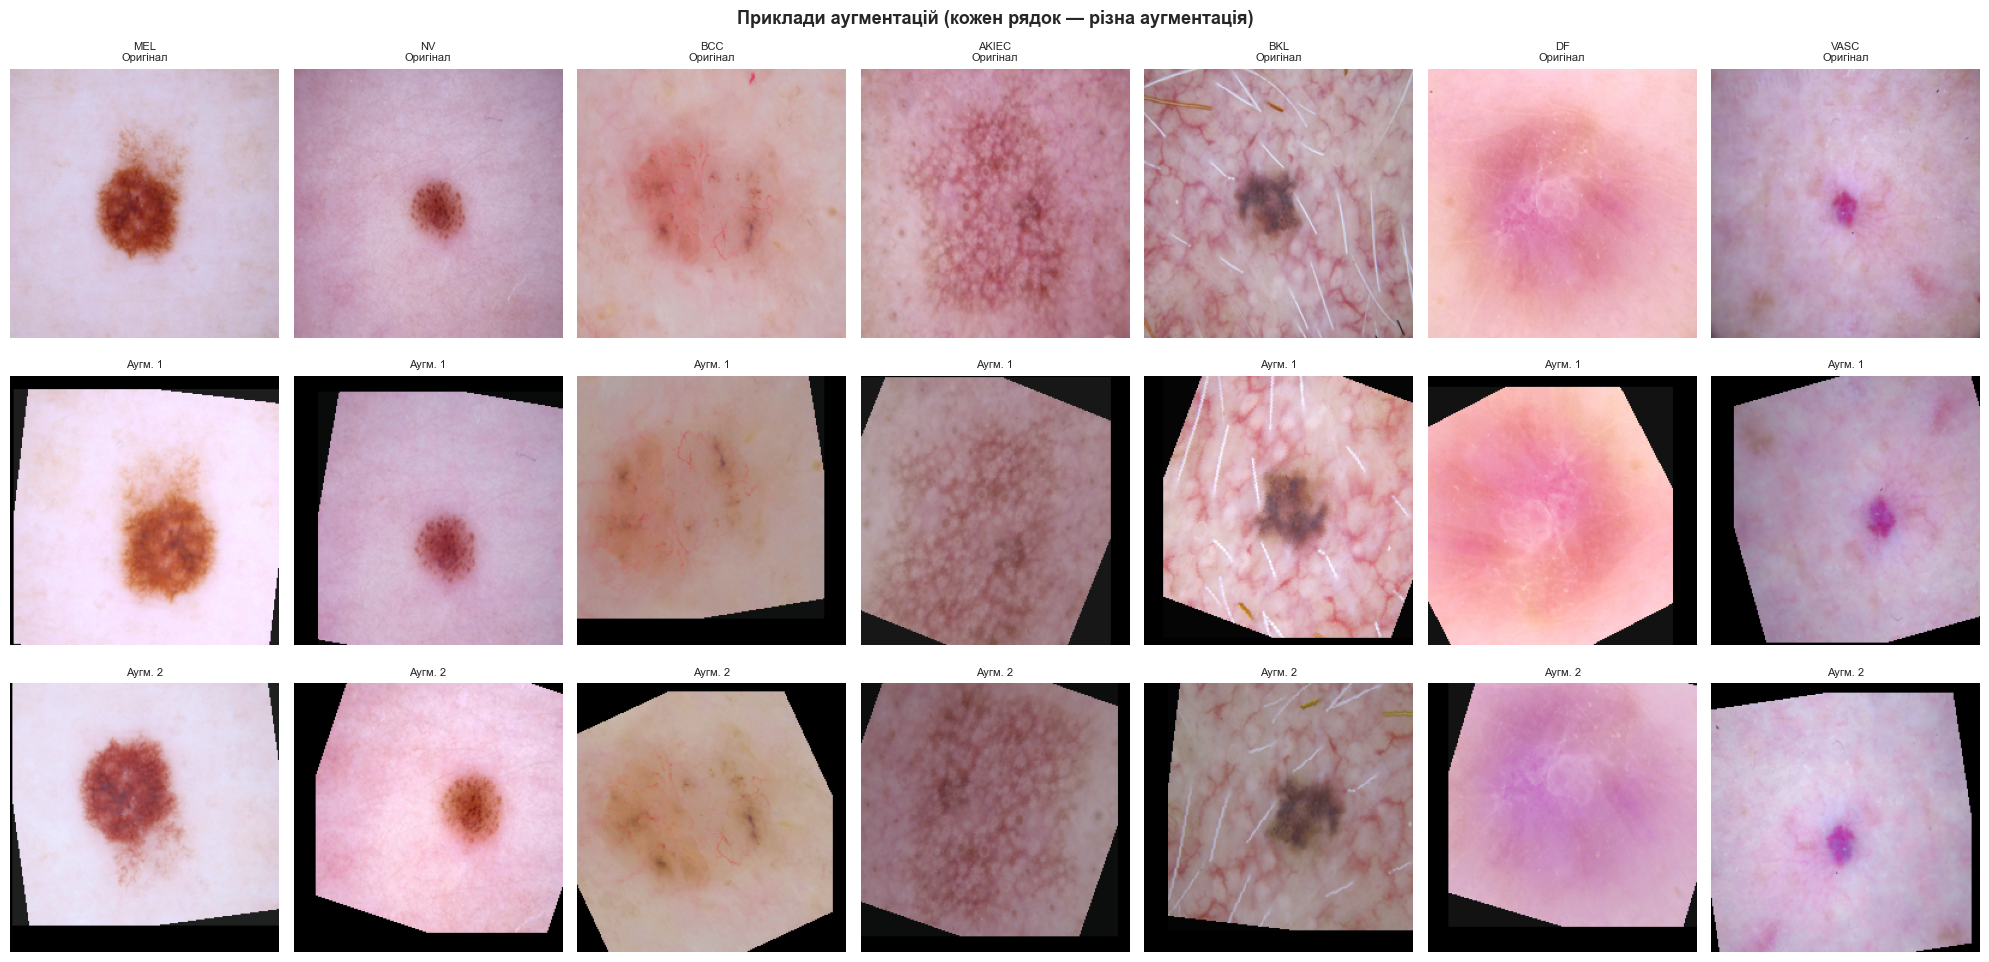

In [10]:
# Візуалізація аугментованих зображень
fig, axes = plt.subplots(3, 7, figsize=(20, 10))
fig.suptitle('Приклади аугментацій (кожен рядок — різна аугментація)', fontsize=13, fontweight='bold')

for col, cls in enumerate(CLASS_NAMES):
    sample = train_df[train_df['class_name'] == cls].sample(1).iloc[0]
    img_path = os.path.join(IMG_DIR, sample['image'] + '.jpg')
    orig = Image.open(img_path).convert('RGB')

    # Оригінал
    axes[0, col].imshow(orig.resize((224, 224)))
    axes[0, col].set_title(f'{cls}\nОригінал', fontsize=8)
    axes[0, col].axis('off')

    # Аугментація 1
    aug1 = train_transform(orig)
    aug1_np = aug1.permute(1,2,0).numpy()
    aug1_np = (aug1_np * np.array(STD) + np.array(MEAN)).clip(0, 1)
    axes[1, col].imshow(aug1_np)
    axes[1, col].set_title('Аугм. 1', fontsize=8)
    axes[1, col].axis('off')

    # Аугментація 2
    aug2 = train_transform(orig)
    aug2_np = aug2.permute(1,2,0).numpy()
    aug2_np = (aug2_np * np.array(STD) + np.array(MEAN)).clip(0, 1)
    axes[2, col].imshow(aug2_np)
    axes[2, col].set_title('Аугм. 2', fontsize=8)
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('augmentations.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Модель — EfficientNet-B3

In [11]:
class SkinClassifier(nn.Module):
    """
    Transfer Learning на базі EfficientNet-B3 (pretrained на ImageNet).
    Остання частина frozen → поступово розморожуємо.
    """
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        # Завантаження pretrained backbone
        self.backbone = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            num_classes=0,    # без класифікатора
            global_pool='avg'
        )
        in_features = self.backbone.num_features  # 1536 для B3

        # Кастомний класифікатор
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(p=dropout / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

    def freeze_backbone(self):
        """Заморожуємо backbone — тренуємо тільки classifier"""
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        """Розморожуємо все для fine-tuning"""
        for param in self.backbone.parameters():
            param.requires_grad = True


model = SkinClassifier(num_classes=7, dropout=0.4).to(device)

# Підрахунок параметрів
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"📊 Параметри моделі:")
print(f"   Total:     {total_params:,}")
print(f"   Trainable: {trainable_params:,}")

📊 Параметри моделі:
   Total:     11,487,791
   Trainable: 11,487,791


## 7. Loss функція — з урахуванням дисбалансу

In [12]:
# Клас-вагована CrossEntropyLoss
class_counts_all = df['label'].value_counts().sort_index().values
total_samples = len(df)
num_classes = 7

# Inverse frequency weighting
weights = total_samples / (num_classes * class_counts_all)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)

print("Loss weights per class:")
for i, (cls, w) in enumerate(zip(CLASS_NAMES, weights)):
    print(f"  {cls:6s}: {w:.4f}")

Loss weights per class:
  MEL   : 1.2855
  NV    : 0.2134
  BCC   : 2.7835
  AKIEC : 4.3753
  BKL   : 1.3018
  DF    : 12.4410
  VASC  : 10.0755


## 8. Training Loop

In [14]:
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        if scaler:  # Mixed precision
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    acc = correct / total
    f1  = f1_score(all_labels, all_preds, average='macro')
    return total_loss / len(loader), acc, f1, all_preds, all_labels, all_probs


print("✅ Training functions defined")

✅ Training functions defined


In [17]:
# ====================================================
# СТРАТЕГІЯ: 2-фазне навчання
# Фаза 1: freeze backbone, тренуємо тільки classifier (5 epochs)
# Фаза 2: unfreeze все, fine-tuning з малим lr (10 epochs)
# ====================================================

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

# ---- ФАЗА 1: Warm-up ----
print("=" * 50)
print("ФАЗА 1: Тренування класифікатора (backbone frozen)")
print("=" * 50)

model.freeze_backbone()

optimizer_phase1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler_phase1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_phase1, T_max=5)
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

PHASE1_EPOCHS = 5
best_f1 = 0

for epoch in range(1, PHASE1_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer_phase1, criterion, scaler)
    val_loss, val_acc, val_f1, _, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler_phase1.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch [{epoch}/{PHASE1_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"   ✅ Saved best model (F1={best_f1:.4f})")

ФАЗА 1: Тренування класифікатора (backbone frozen)


Epoch [1/5] Train Loss: 0.9354 Acc: 0.3929 | Val Loss: 1.4289 Acc: 0.1764 F1: 0.2185
   ✅ Saved best model (F1=0.2185)


Epoch [2/5] Train Loss: 0.7461 Acc: 0.4713 | Val Loss: 1.4571 Acc: 0.2224 F1: 0.2258
   ✅ Saved best model (F1=0.2258)


Epoch [3/5] Train Loss: 0.7193 Acc: 0.4810 | Val Loss: 1.3441 Acc: 0.3009 F1: 0.2546
   ✅ Saved best model (F1=0.2546)


Epoch [4/5] Train Loss: 0.6415 Acc: 0.5260 | Val Loss: 1.3045 Acc: 0.2976 F1: 0.2600
   ✅ Saved best model (F1=0.2600)


Epoch [5/5] Train Loss: 0.6354 Acc: 0.5198 | Val Loss: 1.3201 Acc: 0.3156 F1: 0.2734
   ✅ Saved best model (F1=0.2734)


In [18]:
# ---- ФАЗА 2: Fine-tuning ----
print("=" * 50)
print("ФАЗА 2: Fine-tuning (увесь backbone розморожено)")
print("=" * 50)

model.unfreeze_backbone()

optimizer_phase2 = optim.AdamW([
    {'params': model.backbone.parameters(),   'lr': 1e-5},   # малий lr для backbone
    {'params': model.classifier.parameters(), 'lr': 1e-4},   # більший для класифікатора
], weight_decay=1e-4)

PHASE2_EPOCHS = 15
scheduler_phase2 = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_phase2, T_0=5, T_mult=2
)

patience = 5
patience_counter = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer_phase2, criterion, scaler)
    val_loss, val_acc, val_f1, _, _, _ = eval_epoch(model, val_loader, criterion)
    scheduler_phase2.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Epoch [{epoch}/{PHASE2_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"   ✅ Saved best model (F1={best_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏹️  Early stopping at epoch {epoch + PHASE1_EPOCHS}")
            break

print(f"\n🏆 Best Validation F1: {best_f1:.4f}")

ФАЗА 2: Fine-tuning (увесь backbone розморожено)


KeyboardInterrupt: 

## 9. Криві навчання

In [ ]:
epochs_range = range(1, len(history['train_loss']) + 1)
phase_boundary = PHASE1_EPOCHS  # де закінчується фаза 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Криві навчання', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val',   markersize=4)
axes[0].axvline(x=phase_boundary + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tuning →')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train', markersize=4)
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val',   markersize=4)
axes[1].axvline(x=phase_boundary + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# F1
axes[2].plot(epochs_range, history['val_f1'], 'g-o', label='Val F1-macro', markersize=4)
axes[2].axvline(x=phase_boundary + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[2].set_title('Validation F1-macro'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('F1')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Оцінка на тестовій вибірці

In [ ]:
# Завантажуємо найкращу модель
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# Eval на тесті
test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = eval_epoch(
    model, test_loader, criterion
)

test_probs = np.array(test_probs)

print("=" * 50)
print("РЕЗУЛЬТАТИ НА ТЕСТОВІЙ ВИБІРЦІ")
print("=" * 50)
print(f"Loss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"F1-macro: {test_f1:.4f}")

# ROC-AUC (One-vs-Rest)
try:
    auc = roc_auc_score(
        test_labels, test_probs,
        multi_class='ovr', average='macro'
    )
    print(f"ROC-AUC:  {auc:.4f}")
except Exception as e:
    print(f"ROC-AUC: N/A ({e})")

print()
print(classification_report(
    test_labels, test_preds,
    target_names=[CLASS_LABELS[c] for c in CLASS_NAMES]
))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Confusion Matrix', fontsize=14, fontweight='bold')

short_labels = CLASS_NAMES
full_labels = [CLASS_LABELS[c] for c in CLASS_NAMES]

# Абсолютна
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels, ax=axes[0])
axes[0].set_title('Абсолютні значення')
axes[0].set_ylabel('Справжній клас')
axes[0].set_xlabel('Передбачений клас')

# Нормалізована
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_labels, yticklabels=short_labels, ax=axes[1])
axes[1].set_title('Нормалізована (recall per class)')
axes[1].set_ylabel('Справжній клас')
axes[1].set_xlabel('Передбачений клас')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Per-class metrics bar chart
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(test_labels, test_preds, average=None, zero_division=0)
recall    = recall_score(test_labels, test_preds, average=None, zero_division=0)
f1_per    = f1_score(test_labels, test_preds, average=None, zero_division=0)

x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, precision, width, label='Precision', color='#3498db')
ax.bar(x,         recall,    width, label='Recall',    color='#2ecc71')
ax.bar(x + width, f1_per,    width, label='F1',        color='#e74c3c')

ax.set_xlabel('Клас')
ax.set_ylabel('Значення')
ax.set_title('Метрики по кожному класу', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Grad-CAM — Візуалізація того, на що дивиться модель

In [ ]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRADCAM_AVAILABLE = True
except ImportError:
    GRADCAM_AVAILABLE = False
    print("⚠️  grad-cam не встановлено. Запусти: pip install grad-cam")


if GRADCAM_AVAILABLE:
    # Target layer для EfficientNet-B3
    target_layers = [model.backbone.blocks[-1]]
    cam = GradCAM(model=model, target_layers=target_layers)

    fig, axes = plt.subplots(3, 7, figsize=(21, 10))
    fig.suptitle('Grad-CAM — що модель "бачить" при класифікації', fontsize=14, fontweight='bold')

    for col, cls in enumerate(CLASS_NAMES):
        sample = test_df[test_df['class_name'] == cls]
        if len(sample) == 0:
            continue
        row = sample.sample(1).iloc[0]

        img_path = os.path.join(IMG_DIR, row['image'] + '.jpg')
        orig_img = np.array(Image.open(img_path).convert('RGB').resize((224, 224))) / 255.0
        orig_img = orig_img.astype(np.float32)

        input_tensor = val_test_transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)

        # Prediction
        with torch.no_grad():
            output = model(input_tensor)
            pred_class = output.argmax().item()
            confidence = torch.softmax(output, dim=1)[0, pred_class].item()

        # Grad-CAM
        targets = [ClassifierOutputTarget(pred_class)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
        cam_image = show_cam_on_image(orig_img, grayscale_cam, use_rgb=True)

        # Оригінал
        axes[0, col].imshow(orig_img)
        axes[0, col].set_title(f'GT: {cls}', fontsize=8, fontweight='bold')
        axes[0, col].axis('off')

        # Grad-CAM heatmap
        axes[1, col].imshow(cam_image)
        correct = '✅' if pred_class == int(row['label']) else '❌'
        axes[1, col].set_title(f'{correct} Pred: {CLASS_NAMES[pred_class]}\n{confidence:.1%}', fontsize=7)
        axes[1, col].axis('off')

        # Heatmap
        axes[2, col].imshow(grayscale_cam, cmap='jet')
        axes[2, col].set_title('Heatmap', fontsize=7)
        axes[2, col].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grad-CAM saved")

## 12. Аналіз помилок

In [ ]:
# Знаходимо найгірші передбачення (найвища confidence, але неправильно)
test_probs_arr = np.array(test_probs)
test_preds_arr = np.array(test_preds)
test_labels_arr = np.array(test_labels)

wrong_mask = test_preds_arr != test_labels_arr
wrong_indices = np.where(wrong_mask)[0]
wrong_confidence = test_probs_arr[wrong_indices, test_preds_arr[wrong_indices]]

# Топ-12 найбільш впевнених помилок
top_wrong = wrong_indices[np.argsort(wrong_confidence)[-12:][::-1]]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Найбільш впевнені помилки моделі', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, idx in enumerate(top_wrong):
    img_name = test_df.iloc[idx]['image']
    img_path = os.path.join(IMG_DIR, img_name + '.jpg')
    img = Image.open(img_path).convert('RGB')

    true_cls  = CLASS_NAMES[test_labels_arr[idx]]
    pred_cls  = CLASS_NAMES[test_preds_arr[idx]]
    conf      = wrong_confidence[np.where(top_wrong == idx)[0][0]]

    axes[i].imshow(img.resize((224, 224)))
    axes[i].set_title(
        f'True: {true_cls}\nPred: {pred_cls} ({conf:.1%})',
        color='red', fontsize=9
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Inference — функція для продакшену

In [ ]:
def predict_image(image_path: str, model=model, topk: int = 3):
    """
    Передбачення для одного зображення.
    Повертає топ-k класів з впевненістю.
    
    Args:
        image_path: шлях до зображення
        model: навчена модель
        topk: кількість топ передбачень
    
    Returns:
        dict з результатами
    """
    model.eval()

    # Завантаження та preprocessing
    image = Image.open(image_path).convert('RGB')
    input_tensor = val_test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs  = torch.softmax(output, dim=1)[0].cpu().numpy()

    # Топ-k
    top_indices = probs.argsort()[::-1][:topk]
    results = [
        {
            'class_code':  CLASS_NAMES[i],
            'class_name':  CLASS_LABELS[CLASS_NAMES[i]],
            'confidence':  float(probs[i]),
            'confidence_pct': f"{probs[i]*100:.1f}%"
        }
        for i in top_indices
    ]

    return {
        'top_prediction': results[0],
        'all_top_k': results,
        'all_probabilities': {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))},
        'disclaimer': '⚠️ Це не медичний діагноз. Зверніться до дерматолога.'
    }


# Тест на прикладі
sample_path = os.path.join(IMG_DIR, test_df.sample(1).iloc[0]['image'] + '.jpg')
result = predict_image(sample_path)

print("Результат передбачення:")
print(f"  Клас: {result['top_prediction']['class_name']}")
print(f"  Код: {result['top_prediction']['class_code']}")
print(f"  Впевненість: {result['top_prediction']['confidence_pct']}")
print(f"\nТоп-3:")
for r in result['all_top_k']:
    print(f"  {r['class_code']:6s} ({r['class_name']:25s}): {r['confidence_pct']}")
print(f"\n{result['disclaimer']}")

In [ ]:
# Візуалізація inference результату
def visualize_prediction(image_path: str, model=model):
    result = predict_image(image_path, model)
    image = Image.open(image_path).convert('RGB')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Зображення
    axes[0].imshow(image.resize((224, 224)))
    top = result['top_prediction']
    axes[0].set_title(
        f"Передбачення: {top['class_name']}\nВпевненість: {top['confidence_pct']}",
        fontsize=11, fontweight='bold'
    )
    axes[0].axis('off')

    # Розподіл ймовірностей
    probs_dict = result['all_probabilities']
    sorted_classes = sorted(probs_dict, key=probs_dict.get, reverse=True)
    sorted_probs = [probs_dict[c] for c in sorted_classes]

    bars = axes[1].barh(sorted_classes, sorted_probs, color=colors[::-1])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Ймовірність')
    axes[1].set_title('Розподіл ймовірностей', fontsize=11)

    for bar, val in zip(bars, sorted_probs):
        axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.1%}', va='center')

    # Підсвічуємо найвищий
    bars[0].set_edgecolor('red')
    bars[0].set_linewidth(2)

    plt.tight_layout()
    plt.savefig('inference_example.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_prediction(sample_path)

## 14. Збереження моделі для продакшену

In [ ]:
# Зберігаємо все що треба для деплою
import json

# 1. PyTorch model weights
torch.save(model.state_dict(), 'skin_classifier_weights.pth')

# 2. TorchScript — оптимізована версія для inference
model.eval()
try:
    scripted_model = torch.jit.script(model)
    scripted_model.save('skin_classifier_scripted.pt')
    print("✅ TorchScript saved")
except Exception as e:
    print(f"TorchScript не вийшло ({e}), використовуй weights")

# 3. Метадані
metadata = {
    'model_name': 'EfficientNet-B3 SkinClassifier',
    'num_classes': 7,
    'class_names': CLASS_NAMES,
    'class_labels': CLASS_LABELS,
    'input_size': [224, 224],
    'normalize_mean': MEAN,
    'normalize_std': STD,
    'test_accuracy': round(test_acc, 4),
    'test_f1_macro': round(test_f1, 4),
    'disclaimer': 'NOT a medical diagnosis. Consult a dermatologist.'
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Збережено:")
print("   skin_classifier_weights.pth — ваги моделі")
print("   skin_classifier_scripted.pt — TorchScript")
print("   model_metadata.json          — метадані")
print(f"\n📊 Фінальні результати:")
print(f"   Test Accuracy: {test_acc:.4f}")
print(f"   Test F1-macro: {test_f1:.4f}")

## 15. Висновки

### Що зроблено:
1. **EDA** — проаналізовано дисбаланс класів (NV домінує ~67%)
2. **Preprocessing** — resize 224×224, нормалізація ImageNet
3. **Аугментації** — flip, rotate, color jitter, affine
4. **WeightedRandomSampler** — балансування дисбалансу при навчанні
5. **Weighted CrossEntropyLoss** — додатковий захист від дисбалансу
6. **EfficientNet-B3** — transfer learning з ImageNet
7. **2-фазне навчання** — спочатку warm-up, потім fine-tuning
8. **Grad-CAM** — інтерпретабельність моделі
9. **Аналіз помилок** — розуміння де модель помиляється
10. **Export** — збережено для продакшену

### Обмеження:
- Модель навчена на ~10,000 зображень — невелика вибірка для медичного AI
- ⚠️ **Не є медичним діагнозом** — тільки допоміжний інструмент
- Завжди консультуйтесь з дерматологом

### Наступні кроки для продакшену:
- FastAPI endpoint для inference
- Веб-інтерфейс для завантаження фото
- Docker контейнер
- Моніторинг якості в продакшені